In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re
import sounddevice as sd
import scipy.io.wavfile as wavfile
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from oct2py import Oct2Py
import scipy

from microphone_recorder import MicrophoneAnalyzer

In [2]:
def load_with_gp_smooth_noise(freqs, psd_dbs, freqs_common):
    kernel  = (Matern(length_scale=0.05, length_scale_bounds=(1e-3, 1.0), nu=2.5)
               + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1)))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                  normalize_y=True)
    #convert to log space
    log_freqs = np.log10(freqs)
    
    try:
        gp.fit(log_freqs.reshape(-1,1), psd_dbs)
    except ValueError as e:
        print(f"GP smooth error: {e}")
    mean, std = gp.predict(freqs_common.reshape(-1,1), return_std=True)
    return mean, std

In [3]:
params_df = pd.read_csv("doe_params.csv", index_col=0)   # columns: run_id, mdot, dh_mid, ...

runs = []
for row in params_df.itertuples():
    # Extract data for filename
    index = row.Index
    n_blades = row.n_blade
    mdot = row.mdot
    DHmid = row.DH_mid
    INC = row.incidence
    Vexp = row.Vexp
    lean_max = row.lean_compound
    lean_weighting = int(1.0)
    lean_straight = row.lean_straight
    tip_clearance_percent = np.round(row.tip_clearance,3)
    # filename = f"DOE_{index}_{n_blades}_{mdot}_{DHmid}_{INC}_{Vexp}_{lean_max}_{lean_weighting}_{lean_straight}_{tip_clearance_percent}"
    
    for file in os.listdir("stl_files"):
        match = re.search(f"DOE_{index}", file)
        if match:
            parts = file.split(sep=".")
            # print(parts)
            if parts[-1] == "stl":
                stl_file = file.rstrip(".stl")
    if stl_file is None:
        raise ValueError("No file found")
    filename = f'audio\\doe_data\\{stl_file}.wav'
    
    
    if row.Index == 0:
        break

In [4]:
print(filename)

audio\doe_data\DOE_0_9.0_0.0743611981119211_0.8054925797873145_-4.38755814594996_-1.6759525583862622_3.126742035963525_1_14.287170525537093_3.057blade.wav


In [5]:
def subtract_tonal(freqs, psd, rpm, blade_count, n_harmonics=10, window_bins=5, shoulder_bins=10):
    """
    freqs, psd: output of scipy.signal.welch (psd in linear power, not dB)
    rpm: rotational speed
    blade_count: number of blades
    n_harmonics: how many BPF harmonics to remove
    window_bins: half-width of extraction window around each harmonic (bins)
    shoulder_bins: how many bins either side of window to use for shoulder estimate
    """
    bpf = rpm / 60 * blade_count  # Hz
    psd_broadband = psd.copy()
    tonal_amplitudes = {}
    
    for n in range(1, n_harmonics + 1):
        harmonic_freq = n * bpf
        if harmonic_freq > freqs[-1]:
            break
        
        # Find nearest bin to harmonic
        centre_bin = np.argmin(np.abs(freqs - harmonic_freq))
        
        # Define window and shoulders
        win_start = centre_bin - window_bins
        win_end   = centre_bin + window_bins
        left_shoulder  = psd_broadband[win_start - shoulder_bins : win_start]
        right_shoulder = psd_broadband[win_end : win_end + shoulder_bins]
        
        # Interpolate broadband floor across window (linear in power)
        left_freq  = np.mean(freqs[win_start - shoulder_bins : win_start])
        right_freq = np.mean(freqs[win_end : win_end + shoulder_bins])
        left_level  = np.mean(left_shoulder)
        right_level = np.mean(right_shoulder)
        
        floor = np.interp(
            freqs[win_start:win_end],
            [left_freq, right_freq],
            [left_level, right_level]
        )
        
        # Store tonal amplitude (in dB above floor, at peak bin)
        peak_power = psd_broadband[centre_bin]
        floor_at_peak = floor[window_bins]  # centre of floor estimate
        tonal_amplitudes[n] = 10 * np.log10(peak_power / floor_at_peak)  # dB above floor
        
        # Replace window with interpolated floor
        psd_broadband[win_start:win_end] = floor
    
    return psd_broadband, tonal_amplitudes, bpf

In [6]:
from scipy import signal
# from PCA_DOE_ANALYSIS.pca_core import PCAModel
sample_rate, audio_data = wavfile.read(filename)
# Get just required section
interval = 10
interval_samples = 2 * sample_rate
start_interval = interval * interval_samples 
start_data = start_interval + int(0.2*sample_rate) # audio only starts ~0.2s into recording
end_interval = start_interval + interval_samples 
end_data = end_interval - int(1.4*sample_rate) # throttle adjustment happens ~1s into recording
audio_data = audio_data[start_data:end_data]

n_blades = int(float(re.search(r'DOE_\d+_([\d.]+)_', filename).group(1)))
rpm = 3000
bpf = 3000*n_blades/60
window_length = sample_rate/bpf*100
print(sample_rate, window_length,bpf)
overlap = window_length//2

#window = hanning(82859/12)
freqs, psd = signal.welch(audio_data, sample_rate,
                            window = "hann", nperseg = len(audio_data),
                            scaling = "spectrum") 

# psd_broadband, tonal_amps, bpf = subtract_tonal(freqs, psd, rpm, n_blades)

# 3. Convert to dB (Reference = 1.0 for dBFS/Hz)
psd_db = 10 * np.log10(psd + 1e-12)
# psd_broadband = 10 * np.log10(psd_broadband + 1e-12)

# # Downscale to reduce time
# log_idx = np.unique(
#     np.round(np.logspace(0, np.log10(len(freqs)-1), 400)).astype(int)
# )
# freqs_downscaled, psd_db_downscaled, psd_broadband_downscaled = freqs[log_idx], psd_db[log_idx],psd_broadband[log_idx]

# freqs_common = 2*np.logspace(1,4, 100)

# smooth_dbs, std = load_with_gp_smooth_noise(freqs_downscaled, psd_db_downscaled, np.log10(freqs_common))
# smooth_dbs_broadband, std_bb = load_with_gp_smooth_noise(freqs_downscaled, psd_broadband_downscaled, np.log10(freqs_common))

fs, background_audio = wavfile.read("background.wav")
fs, motor_only_audio = wavfile.read("motor_on.wav")

background_audio= background_audio/np.max(audio_data) 
motor_only_audio= motor_only_audio/np.max(audio_data)

f_bg, psd_bg = signal.welch(background_audio, fs,
                            window = "hann", nperseg = len(audio_data),
                            scaling = "density") 
f_mo, psd_mo = signal.welch(motor_only_audio, fs,
                            window = "hann", nperseg = len(audio_data),
                            scaling = "density") 

fig, ax = plt.subplots(figsize=(10,7))
for i in [""]:#["bartlett","hann"]:#["hann", "hamming", "bartlett", "blackman", "flattop"]:#, sample_rate/(bpf)*50, sample_rate/(bpf)*10,sample_rate/(bpf)]:
    freqs, psd = signal.welch(audio_data, sample_rate,
                            window = "blackman", nperseg = len(audio_data)/4,
                            scaling = "density") 
    psd_db = 10 * np.log10(psd + 1e-12)
    ax.semilogx(freqs/bpf, psd_db ,label=f"blackman: resolution {sample_rate/(len(audio_data)/4):.2f}")#, color='royalblue')
    
# ax.semilogx(f_bg/bpf, 10*np.log(psd_bg+1e-12) ,label=f"bg")
# ax.semilogx(f_mo/bpf, 10*np.log(psd_mo+1e-12) ,label=f"mo")

# ax.semilogx(freqs_downscaled, psd_db_downscaled,label=f"Downscaled", color='green')
# ax.semilogx(freqs, psd_broadband,label=f"Broadband", color='black')
# ax.semilogx(freqs_downscaled, psd_broadband_downscaled,label=f"BroadbandDownscaled", color='yellow')

# ax.semilogx(freqs_common, smooth_dbs,label=f"Smoothed GP PSD", color='red')
# ax.semilogx(freqs_common, smooth_dbs_broadband,label=f"Smoothed GP PSD Broadband", color='pink')

# ax.fill_between(freqs_common, smooth_dbs-std, smooth_dbs+std, alpha=0.3)
# ax.axvline(1, color='red', linestyle='--', alpha=0.6, label=f'BPF ({bpf:.1f} Hz)')
# ax.axvline(2, color='red', linestyle='--', alpha=0.6, label=f'2BPF ({bpf*2:.1f} Hz)')
# ax.axvline(3, color='red', linestyle='--', alpha=0.6, label=f'3BPF ({bpf*3:.1f} Hz)')
# ax.axvline(4, color='red', linestyle='--', alpha=0.6, label=f'4BPF ({bpf*4:.1f} Hz)')
# x=0.55
# ax.axvline(x, color='purple', linestyle='--', alpha=0.6)
# ax.axvline(2*x, color='purple', linestyle='--', alpha=0.6)
# ax.axvline(3*x, color='purple', linestyle='--', alpha=0.6)
# x2=50/450
# ax.axvline(x2, color='green', linestyle='--', alpha=0.6)
# ax.axvline(2*x2, color='green', linestyle='--', alpha=0.6)
# ax.axvline(3*x2, color='green', linestyle='--', alpha=0.6)
# x3=50/450
# ax.axvline(4*x3, color='yellow', linestyle='--', alpha=0.6)
# ax.axvline(5*x3, color='yellow', linestyle='--', alpha=0.6)
# ax.axvline(6*x3, color='yellow', linestyle='--', alpha=0.6)

# ax.axvline(7*x3, color='yellow', linestyle='--', alpha=0.6)
# ax.axvline(8*x3, color='yellow', linestyle='--', alpha=0.6)
# ax.axvline(9*x3, color='yellow', linestyle='--', alpha=0.6)

# ax.axvline(10*x3, color='yellow', linestyle='--', alpha=0.6)
# ax.axvline(11*x3, color='yellow', linestyle='--', alpha=0.6)
# ax.axvline(12*x3, color='yellow', linestyle='--', alpha=0.6)
# ax.axvline(50*3, color='purple', linestyle='--', alpha=0.6, label=f'3*50 Hz')
# # ax.text(bpf * 1.1, np.max(psd_db), 'BPF', color='red', fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD [dB/Hz] (ref: 1.0)')
ax.set_title('PSD')
# ax.set_xlim(1e-1,1e1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

44100 9800.0 450.0


FileNotFoundError: [Errno 2] No such file or directory: 'background.wav'

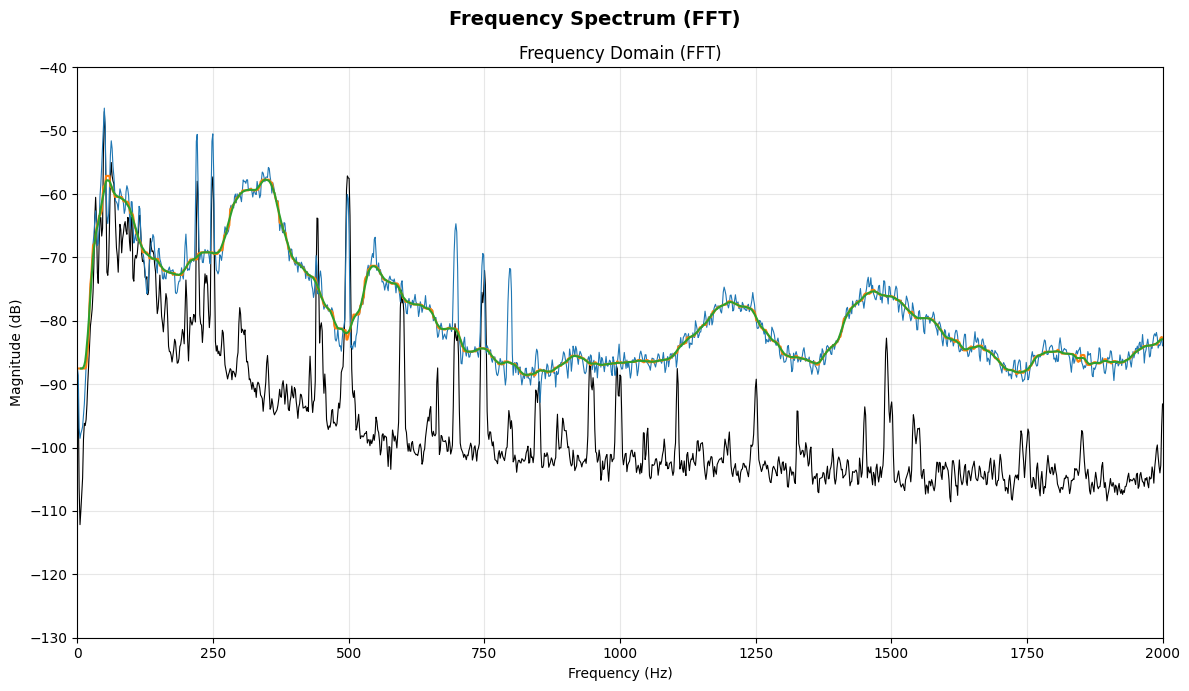

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from scipy.signal import welch
from scipy.signal import medfilt
import os
import re
import pandas as pd

def take_clean_sect(audio_path, section=5):
    sample_rate, audio_data = wavfile.read(audio_path)
    # # Get just required section
    # interval = section
    # interval_samples = 2 * sample_rate
    # start_interval = interval * interval_samples 
    # start_data = start_interval + int(0.2*sample_rate) # audio only starts ~0.2s into recording
    # end_interval = start_interval + interval_samples 
    # end_data = end_interval - int(1.4*sample_rate) # throttle adjustment happens ~1s into recording
    # audio_data = audio_data[start_data:end_data]
    
    return sample_rate, audio_data

def extract_filename(index):
    stl_file = None
    # print(sorted(os.listdir(r"data\doe_data"), key=lambda f: int(re.search(r'\d+', f).group())))
    for file in sorted(os.listdir(r"data\doe_data"), key=lambda f: int(re.search(r'\d+', f).group())):
        match = re.search(f"DOE_{index}", file)
        # print(file, match)
        if match:
            parts = file.split(sep=".")
            if parts[-1] == "csv":
                stl_file = file.rstrip(".csv")
                break
    if stl_file is None:
        raise ValueError("No file found")
    
    filename = f'audio\\doe_data_2\\{stl_file}.wav'
    # print(filename) 
    return filename

def plot_frequency_spectrum():
    """
    Plot the frequency spectrum of audio data using FFT.
    
    Args:
        audio_path: Path to a .wav file (optional)
        sample_rate: Sample rate in Hz (used if generating test signal)
        duration: Duration in seconds (used if generating test signal)
    """
    
    # --- Plot ---
    fig, axes = plt.subplots(figsize=(12, 7))
    fig.suptitle("Frequency Spectrum (FFT)", fontsize=14, fontweight="bold")
    blade_nos = [9,9,7,9,6]
    
    # Calculate motor amplitude
    sample_rate, data = wavfile.read(r"audio\recording_motor_only_20260522_103803.wav")   
    nperseg = len(data)//8
    noverlap = nperseg//2
    
    frequencies, power = welch(
            data,
            fs=sample_rate,
            window='blackman',
            nperseg=nperseg,
            noverlap=noverlap,
            scaling = 'spectrum'
        )

    amplitude = np.sqrt(power) #- motor_amplitude
    amplitude_db = 20 * np.log10(amplitude + 1e-12)   

    axes.plot(frequencies, amplitude_db, linewidth=0.8, label=f'motor', color='k')
    
    params_df = pd.read_csv("doe_params.csv", index_col=0)   # columns: run_id, mdot, dh_mid, ...
    
    
    for row in params_df.itertuples():
        
        i = row.Index
        if i != 79:
            continue
        
        # Extract data for filename
        blade_number = int(row.n_blade)
        filename = extract_filename(row.Index)
        bpf = 50*blade_number

        sample_rate, data = wavfile.read(filename)   
        
        nperseg = len(data)//8
        noverlap = nperseg//2  
        
        ## Plot ##
        frequencies, power = welch(
            data,
            fs=sample_rate,
            window='blackman',
            nperseg=nperseg,
            noverlap=noverlap,
            scaling = 'spectrum'
            )

        amplitude = np.sqrt(power)
        amplitude_db = 20 * np.log10(amplitude + 1e-12)  
        
          
        axes.plot(frequencies, amplitude_db, linewidth=0.8, label=f'Blade{i}, bpf={bpf}')#, color=colours[i])
        
        amplitude_db = medfilt(amplitude_db, kernel_size=19)  # kernel must be odd
        
        axes.plot(frequencies, amplitude_db, linewidth=1.5, label=f'Blade{i}, bpf={bpf}')


    axes.set_title(f"Frequency Domain (FFT)")
    axes.set_xlabel("Frequency (Hz)")
    axes.set_ylabel("Magnitude (dB)")
    axes.grid(True, alpha=0.3)
    # axes.legend()
    axes.set_xlim(0,2000)
    # axes.set_xlim(000,6000)
    axes.set_ylim(-130,-40)

    plt.tight_layout()
    plt.show()

    return

plot_frequency_spectrum()

In [44]:
from IPython.display import Audio, display
display(Audio(background_audio.T if background_audio.ndim == 2 else background_audio, rate=fs))
display(Audio(motor_only_audio.T if motor_only_audio.ndim == 2 else motor_only_audio, rate=fs))
display(Audio(audio_data.T if audio_data.ndim == 2 else audio_data, rate=fs))

In [18]:
print(1/bpf)
print(1/sample_rate)
print((1/bpf)/(1/sample_rate))
print(sample_rate/window_length)

0.0022222222222222222
2.2675736961451248e-05
98.0
450.0


In [ ]:
print(sample_rate/bpf)

98.0


In [15]:
file_path_sqat = r"C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\SQAT-main"
oc = Oct2Py()
oc.addpath(oc.genpath(file_path_sqat))
oc.eval('pkg load signal')

In [16]:
result_sqat = oc.PsychoacousticAnnoyance_Widmann1992(audio_data, sample_rate,0,0,'true','true')

In [25]:
print(type(result_sqat))

<class 'oct2py.io.Struct'>


In [23]:
fs = sample_rate
nperseg = sample_rate//4
delta_f = fs / nperseg

bpf = 3000 / 60 * 5  # in Hz
print(f"Frequency resolution: {delta_f:.2f} Hz")
print(f"BPF: {bpf:.2f} Hz")
print(f"Bins per BPF: {bpf / delta_f:.1f}")

Frequency resolution: 4.00 Hz
BPF: 250.00 Hz
Bins per BPF: 62.5


In [13]:
filename = f'audio\\doe_data\\{stl_file}.wav'
micObj = MicrophoneAnalyzer()

In [4]:
sample_rate, audio_data = wavfile.read(filename)
sample_rate = 44100
# Calculate samples per 3-second interval
interval_samples = 3 * sample_rate
# Split into 3-second chunks
num_intervals = len(audio_data) // interval_samples

for i in range(num_intervals):
    if i==20:
        start = i * interval_samples
        end = start + interval_samples
        interval = audio_data[start:end]
        
        # Now analyze this interval
        print(f"Interval {i+1}: shape {interval.shape}")


Interval 21: shape (132300,)


In [5]:
sd.play(interval*8, samplerate=sample_rate)

In [19]:
print(sample_rate)

44100


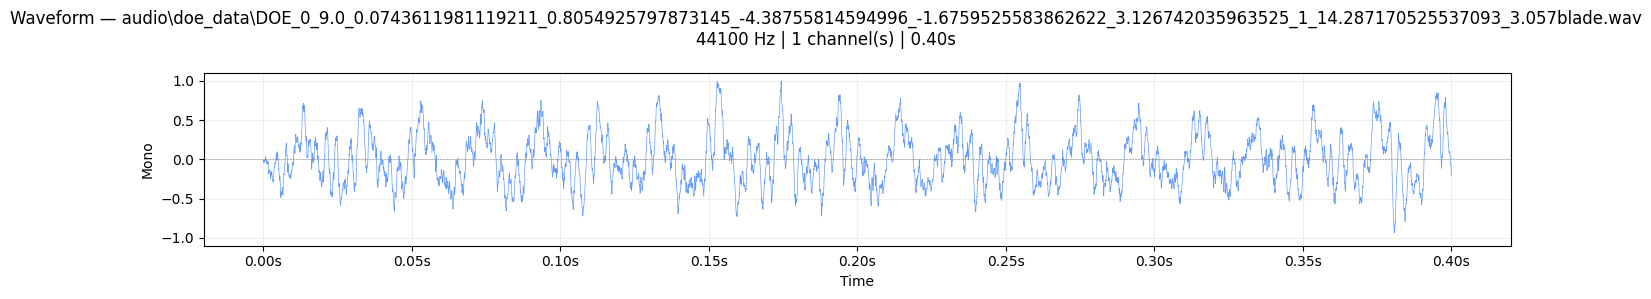

▶ Audio player:


In [44]:
import matplotlib.ticker as ticker
from IPython.display import Audio, display
# --- Load your WAV file ---
file_path = filename  # <-- change this
sample_rate, data = wavfile.read(file_path)

interval = 10
sample_rate = 44100
interval_samples = 2 * sample_rate
start_interval = interval * interval_samples 
start_data = start_interval + int(0.2*sample_rate) # audio only starts ~0.2s into recording
end_interval = start_interval + interval_samples 
end_data = end_interval - int(1.4*sample_rate) # throttle adjustment happens ~1s into recording
data = data[start_data:end_data]

# Handle stereo: convert to mono for display, or keep both channels
if data.ndim == 2:
    channels = [data[:, i] for i in range(data.shape[1])]
    channel_labels = [f"Channel {i+1}" for i in range(data.shape[1])]
else:
    channels = [data]
    channel_labels = ["Mono"]

# Normalize to float in [-1, 1] for consistent plotting
def normalize(d):
    max_val = d.max()
    return d.astype(np.float64) / max_val

# --- Plot waveform ---
time = np.linspace(0, len(data) / sample_rate, num=len(data))

fig, axes = plt.subplots(len(channels), 1, figsize=(14, 3 * len(channels)), squeeze=False)
fig.suptitle(f"Waveform — {file_path}\n{sample_rate} Hz | {len(channels)} channel(s) | {len(data)/sample_rate:.2f}s", fontsize=12)

for ax, ch, label in zip(axes[:, 0], channels, channel_labels):
    norm = normalize(ch)
    ax.plot(time, norm, linewidth=0.5, color="#4C8BF5", alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
    ax.set_ylabel(label, fontsize=10)
    ax.set_ylim(-1.1, 1.1)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.2f}s"))
    ax.grid(True, alpha=0.2)

axes[-1, 0].set_xlabel("Time", fontsize=10)
plt.tight_layout()
plt.show()

# --- Audio player ---
print("▶ Audio player:")
display(Audio(data.T if data.ndim == 2 else data, rate=sample_rate))

In [45]:
print(type(data.max()))

<class 'numpy.float32'>


In [46]:
micObj.audio_data = data


AUDIO ANALYSIS

Time-Domain Analysis:
  RMS Level: 0.003388
  Peak Level: 0.010590
  Mean Level: 0.000035
  Standard Deviation: 0.003388

Zero Crossing Rate: 0.015872

Frequency-Domain Analysis:
  Dominant Frequency: 50.00 Hz
  Frequency Range: 2.50 - 22048.75 Hz

Energy by Frequency Band:
  Sub-bass (20-60 Hz): 3.494981
  Bass (60-250 Hz): 1.575747
  Midrange (250-2000 Hz): 0.380309
  Treble (2000-6000 Hz): 0.056871
  High-treble (6000+ Hz): 0.004675

✓ Analysis plot saved as: audio\audio_analysis_20260428_163449.png


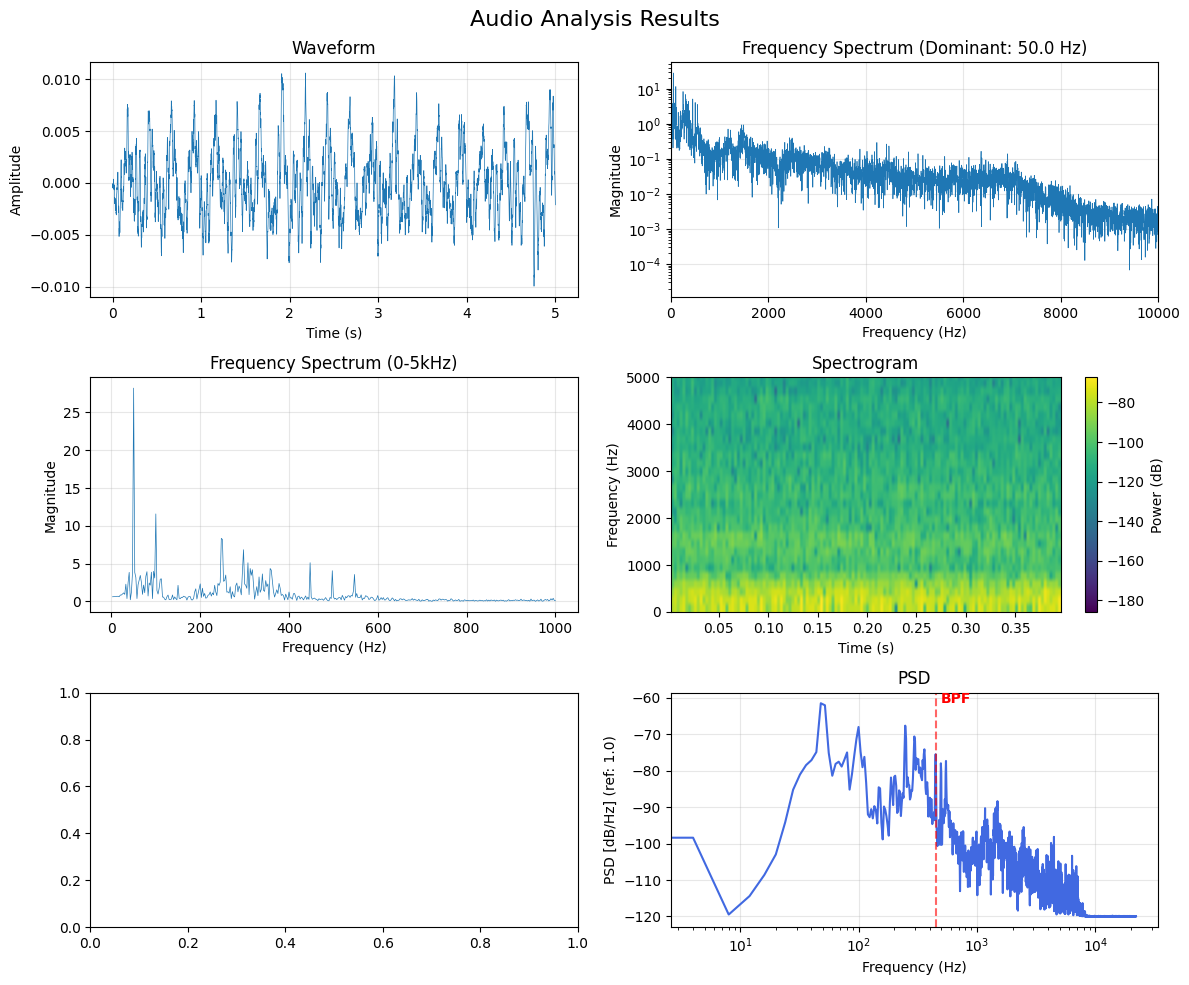

In [47]:
micObj.plot_results(micObj.analyze_audio())

In [32]:
from scipy.fft import fft, fftfreq, rfft, rfftfreq
from scipy.signal import stft

In [30]:
def a_weighting(self, n_fft):
        """Calculates A-weighting coefficients for each frequency bin."""
        freqs = rfftfreq(n_fft, 1/self.sample_rate)
        # Avoid log of zero at 0Hz
        f = np.where(freqs == 0, 1e-10, freqs)
        
        # Standard IEC 61672-1:2003 A-weighting formula
        f1 = 20.602
        f2 = 107.652
        f3 = 737.862
        f4 = 12194.217
        a1000 = -2.000 # Normalization factor to ensure 1kHz = 0dB
        
        num = (12194.217**2) * (f**4)
        den = ((f**2 + f1**2) * np.sqrt((f**2 + f2**2) * (f**2 + f3**2)) * (f**2 + f4**2))
        
        # Calculate weight in dB
        ra_f = 20 * np.log10(num / den) - a1000
        return ra_f

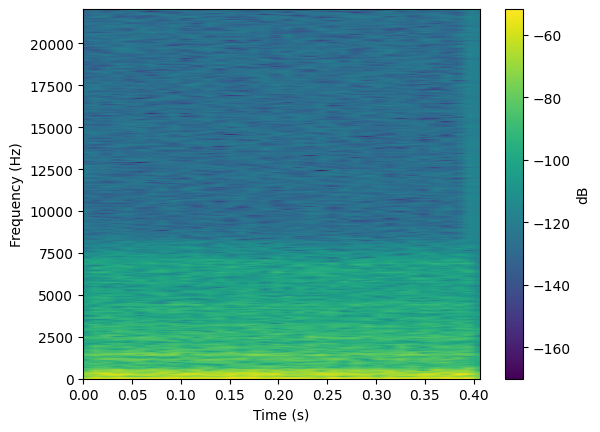

In [34]:
f, t, Zxx = stft(audio_data, fs=sample_rate, nperseg=1024, noverlap=512)

# Magnitude spectrogram
magnitude = np.abs(Zxx)

# In dB (spectrogram)
spectrogram_dB = 20 * np.log10(magnitude + 1e-10)  # +tiny to avoid log(0)

# Plot
plt.pcolormesh(t, f, spectrogram_dB, shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar(label='dB')
plt.show()

In [ ]:
def overall_a_spl(audio_data):
        
        try:
            audio = audio_data.flatten()
        except Exception:
            print("No data found!")
        
        
        # Perform FFT (Real-valued FFT for efficiency)
        n = len(audio)
        fft_data = rfft(audio)
        # Normalize magnitude so 1.0 peak in time = 1.0 peak in frequency
        magnitudes = np.abs(fft_data) * (2 / n) 
        
        plt.loglog()

        # 3. Get A-weighting curve
        weights_db = a_weighting(n)

        # 4. Apply weighting
        # Convert magnitudes to dB, add weights, then convert back to linear power
        # Using 1.0 as the digital reference (dBFS)
        mags_db = 20 * np.log10(magnitudes + 1e-12) # +1e-12 to avoid log(0)
        a_weighted_mags_db = mags_db + weights_db

        # 5. Calculate Overall Level
        # Summing power (squared pressure) is the correct way to get 'total' sound level
        total_power = np.sum(10**(a_weighted_mags_db / 10))
        total_db_a = 10 * np.log10(total_power)

        # print(f"Overall Level: {total_db_a:.2f} dBFS(A)")
        return total_db_a

OASPL(A): 145.8 dBA


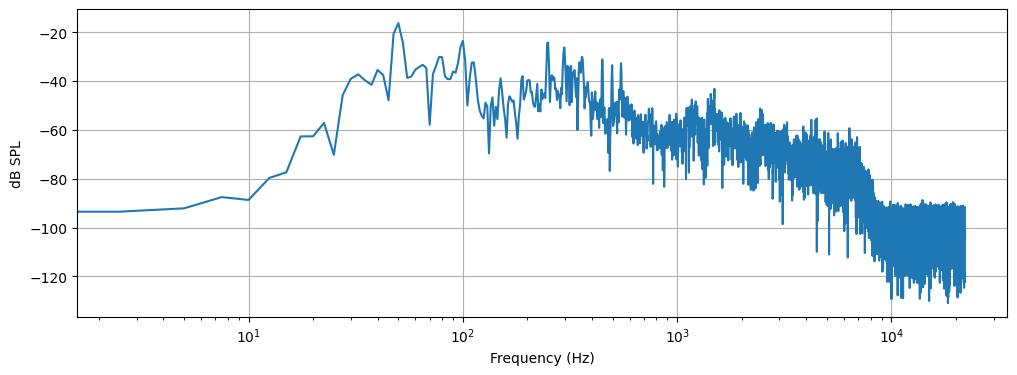

In [43]:
from scipy.io import wavfile
from scipy.fft import rfft, rfftfreq
from scipy.signal import lfilter
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import bilinear, sosfilt, butter

# fs, data = wavfile.read('fan.wav')
data = audio_data
fs = sample_rate
data = data/data.max()

def a_weight_filter(fs):
    # A-weighting filter coefficients (IEC 61672)
    f1 = 20.598997
    f2 = 107.65265
    f3 = 737.86223
    f4 = 12194.217
    A1000 = 1.9997

    numerator = [(2 * np.pi * f4)**2 * (10**(A1000/20)), 0, 0, 0, 0]
    denominator = np.polymul(
        [1, 4*np.pi*f1, (2*np.pi*f1)**2],
        [1, 4*np.pi*f4, (2*np.pi*f4)**2]
    )
    # Use bilinear transform to get digital filter
    b, a = bilinear(numerator, denominator, fs)
    return b, a

# --- Time domain: A-weighted OASPL ---
b, a = a_weight_filter(fs)  # as defined earlier
data_Aw = lfilter(b, a, data)
OASPL_A = 20 * np.log10(np.sqrt(np.mean(data_Aw**2)))
print(f"OASPL(A): {OASPL_A:.1f} dBA")

# --- Frequency domain: narrow band spectrum ---
N = len(data)
window = np.hanning(N)
spectrum = np.abs(rfft(data * window)) / (N/2)  # normalised pressure amplitude
freqs = rfftfreq(N, d=1/fs)

# Convert to dB SPL
spectrum_dB = 20 * np.log10(spectrum + 1e-10)

plt.figure(figsize=(12, 4))
plt.semilogx(freqs, spectrum_dB)
plt.xlabel('Frequency (Hz)')
plt.ylabel('dB SPL')
# plt.title('Fan noise narrow-band spectrum')
# plt.xlim([0, 5000])
plt.grid(True)
plt.show()

In [38]:
print(type(audio_data[0]))

<class 'numpy.float32'>
